# Mid-Term Project: Multi-Constraint Portfolio Allocation

**Student Name:** [Trevor Tilley]
**Date:** [3-10-2026]
**Chosen context:** [Cyber Security Analytics]


## Project Overview

You will choose a resource allocation problem in your field, create a synthetic dataset with **8–10 options**, build a **multi-constraint optimization model**, explore **near-optimal alternatives**, run deep sensitivity analysis and validation, then respond to **two stakeholder changes of mind**. The deliverable is one notebook with clear documentation and an executive summary suitable to hand off to a manager.

**Learning Objectives:**
- Build a multi-constraint continuous LP in PuLP (budget cap, category coverage, concentration cap)
- Diagnose and handle infeasibility when constraints interact
- Identify near-optimal alternative solutions and explain why they might be preferred
- Perform sensitivity analysis across 5 parameters at ±20% and ±40%
- Apply extreme value testing and one additional what-if scenario
- Validate the solution with sanity checks and a fragile vs. robust assessment
- Respond to two stakeholder changes of mind with updated models and a three-way comparison
- Communicate findings in an executive summary suitable for a non-technical decision-maker

In [45]:
# Install required packages (if needed in Colab)
# Skip if running locally and packages are already installed
%pip install pulp pandas matplotlib numpy -q

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pulp import LpMaximize, LpMinimize, LpProblem, LpVariable, lpSum, value, LpStatus, PULP_CBC_CMD
import io

print("Libraries imported successfully!")

Libraries imported successfully!


---
## Creating My Synthetic Dataset


In [47]:
# Paste your CSV here and set the three constraint values.
# Replace the example below with your actual data from the LLM.

csv_string = """
option,category,benefit_rate,risk_score
Endpoint_Monitoring,Prevention,0.07,3
Email_Filtering,Prevention,0.06,2
Threat_Intel_Platform,Detection,0.08,4
SIEM_Tuning,Detection,0.05,3
User_Training,Prevention,0.04,1
Incident_Response_Team,Response,0.09,5
Backup_Recovery_Upgrade,Response,0.06,2
Vulnerability_Scanning,Detection,0.05,3
"""

options_df = pd.read_csv(io.StringIO(csv_string.strip()))

# Three global constraint values — set these based on what the LLM gave you
budget_total         = 100000  # Total resource available (e.g. dollars, hours)
min_alloc_per_category = 10000  # Each category must receive at least this much
concentration_cap = 0.4    # No single option gets more than this fraction of budget_total

# Derived check value (used later)
max_single_alloc = concentration_cap * budget_total

# ── Display ────────────────────────────────────────────────────────────────────
print(options_df.to_string(index=False))
print(f"\nNumber of options: {len(options_df)}")
print(f"Number of categories: {options_df['category'].nunique()} — {list(options_df['category'].unique())}")
print(f"\nConstraint values:")
print(f"  budget_total           = {budget_total:,}")
print(f"  min_alloc_per_category = {min_alloc_per_category:,}")
print(f"  concentration_cap      = {concentration_cap} (max single option = {max_single_alloc:,.0f})")

# Quick feasibility pre-check
feasibility_ok = (min_alloc_per_category * 3 < budget_total) and (max_single_alloc >= min_alloc_per_category)
print(f"\nPre-check: {'✓ Constraint values look feasible' if feasibility_ok else '⚠ WARNING: constraint values may cause immediate infeasibility — adjust before proceeding'}")

                 option   category  benefit_rate  risk_score
    Endpoint_Monitoring Prevention          0.07           3
        Email_Filtering Prevention          0.06           2
  Threat_Intel_Platform  Detection          0.08           4
            SIEM_Tuning  Detection          0.05           3
          User_Training Prevention          0.04           1
 Incident_Response_Team   Response          0.09           5
Backup_Recovery_Upgrade   Response          0.06           2
 Vulnerability_Scanning  Detection          0.05           3

Number of options: 8
Number of categories: 3 — ['Prevention', 'Detection', 'Response']

Constraint values:
  budget_total           = 100,000
  min_alloc_per_category = 10,000
  concentration_cap      = 0.4 (max single option = 40,000)

Pre-check: ✓ Constraint values look feasible


**Data documentation:**

I used a language model to generate a synthetic dataset containing 8 options across three categories (Prevention, Detection, and Response) with benefit_rate and risk_score values, along with constraint values of budget_total = 100000, min_alloc_per_category = 10000, and concentration_cap = 0.4.

---
## Part 1: Problem Framing and Dataset

### 1.1 Decision Statement

I need to decide how to allocate a $100,000 cybersecurity budget across eight security initiatives, subject to minimum category allocations, a concentration cap on any single initiative, and the total budget constraint, in order to maximize the expected security benefit return.

### 1.2 Decision Variables vs Inputs



**Decision Variables (what the model decides):**
The amount of budget allocated to each of the 8 cybersecurity initiatives (alloc_Endpoint_Monitoring, alloc_Email_Filtering, alloc_Threat_Intel_Platform, alloc_SIEM_Tuning, alloc_User_Training, alloc_Incident_Response_Team, alloc_Backup_Recovery_Upgrade, alloc_Vulnerability_Scanning).

**Inputs (what I provide to the model):**
The benefit_rate for each option, the risk_score for each option, the category assignment for each option (Prevention, Detection, Response), and the constraint parameters budget_total = 100000, min_alloc_per_category = 10000, and concentration_cap = 0.4.

**Explanation:**
Decision variables represent the allocation amounts the optimization model determines, while inputs are the known parameters and constraints provided to the model that guide how the allocations can be made and how the objective function is calculated.

### 1.3 Objectives and Constraints


**Objective:**
Maximize the total expected cybersecurity benefit by allocating the budget across all options, calculated as the sum of (benefit_rate × allocation) for each option.

**Constraint 1 — Budget Cap (hard):**
The total allocation across all eight cybersecurity initiatives cannot exceed $100,000 because this represents the fixed cybersecurity budget available.

**Constraint 2 — Category Coverage (hard):**
Each of the three categories (Prevention, Detection, and Response) must receive at least $10,000 to ensure balanced investment across different areas of cybersecurity, since organizational security policy requires minimum coverage in each defensive layer.

**Constraint 3 — Concentration Cap (hard):**
No single cybersecurity initiative may receive more than 40% of the total budget ($40,000) because allocating too much to one option would create excessive dependence on a single security control and increase overall operational risk.

### 1.4 Key Parameters and Uncertainty


| # | Parameter | Source | Why it might differ from reality | Estimated uncertainty |
|---|-----------|--------|-----------------------------------|-----------------------|
| 1 | benefit_rate (all options) | Estimated expected security return based on industry benchmarks and assumed effectiveness of each cybersecurity initiative | Actual security improvements may differ due to evolving threats, implementation quality, or organizational environment | ±25% |
| 2 | benefit_rate (top option only) | Estimated return for the highest-rated option (Incident_Response_Team) based on assumed impact of faster breach containment | The real-world impact of incident response improvements may vary depending on the type and frequency of attacks | ±30% |
| 3 | budget_total | Organizational cybersecurity budget planning estimate for the period | The approved budget could increase or decrease due to leadership decisions or shifting organizational priorities | ±20% |
| 4 | min_alloc_per_category | Internal policy requirement to maintain balanced investment across Prevention, Detection, and Response | Security leadership may adjust minimum spending requirements depending on current threat priorities | ±30% |
| 5 | concentration_cap | Risk management guideline limiting overinvestment in a single initiative | Leadership may change acceptable risk levels or allow higher concentration if a particular control proves highly effective | ±10% |

---
## Part 2: Optimization Model and Near-Optimal Exploration

### 2.1 Build and Solve the Base Model


In [48]:
# ── Base model setup ──────────────────────────────────────────────────────────
n          = len(options_df)
categories = options_df['category'].unique()

# Confirmed column name from CSV
benefit_col = 'benefit_rate'

model_base = LpProblem("Portfolio_Base", LpMaximize)

# Decision variables: how much to allocate to each option (continuous, ≥ 0)
alloc = [LpVariable(f"alloc_{i}", lowBound=0) for i in range(n)]

# ── Objective ──────────────────────────────────────────────────────────────────
# Maximize total expected benefit
model_base += lpSum([alloc[i] * options_df.iloc[i][benefit_col]
                     for i in range(n)]), "Total_Benefit"

# ── Constraint 1: Budget cap ───────────────────────────────────────────────────
# Total allocation cannot exceed the total budget
model_base += lpSum(alloc) <= budget_total, "Budget_Cap"

# ── Constraint 2: Category coverage ───────────────────────────────────────────
# Each category must receive at least min_alloc_per_category
for cat in categories:
    cat_idx = options_df.index[options_df['category'] == cat].tolist()
    model_base += (lpSum([alloc[i] for i in cat_idx]) >= min_alloc_per_category,
                   f"Coverage_{cat}")

# ── Constraint 3: Concentration cap ───────────────────────────────────────────
# No single option may receive more than concentration_cap × budget_total
for i in range(n):
    model_base += (alloc[i] <= concentration_cap * budget_total,
                   f"Cap_{options_df.iloc[i, 0]}")

# ── Solve ──────────────────────────────────────────────────────────────────────
model_base.solve(PULP_CBC_CMD(msg=0))

# ── Results ───────────────────────────────────────────────────────────────────
print(f"Status: {LpStatus[model_base.status]}")
print()

if model_base.status == 1:   # Optimal
    base_allocs = [value(alloc[i]) for i in range(n)]
    base_obj    = value(model_base.objective)

    print(f"Objective (total benefit): {base_obj:.4f}")
    print(f"Total allocated: {sum(base_allocs):,.2f}  /  budget: {budget_total:,}")
    print()
    print(f"{'Option':<20} {'Category':<12} {'Allocated':>12} {'% of budget':>12}")
    print("-" * 60)
    for i in range(n):
        opt  = options_df.iloc[i, 0]
        cat  = options_df.iloc[i]['category']
        alloc_val = base_allocs[i]
        pct  = 100 * alloc_val / budget_total
        print(f"{opt:<20} {cat:<12} {alloc_val:>12,.2f} {pct:>11.1f}%")
    print()
    print("Category totals:")
    for cat in categories:
        cat_idx   = options_df.index[options_df['category'] == cat].tolist()
        cat_total = sum(base_allocs[i] for i in cat_idx)
        print(f"  {cat}: {cat_total:,.2f}  (min required: {min_alloc_per_category:,})")

elif model_base.status == -1:  # Infeasible
    print("⚠ INFEASIBLE — see Section 2.2 below for diagnosis and how to relax.")
else:
    print(f"Solver returned status: {LpStatus[model_base.status]}")

Status: Optimal

Objective (total benefit): 8200.0000
Total allocated: 100,000.00  /  budget: 100,000

Option               Category        Allocated  % of budget
------------------------------------------------------------
Endpoint_Monitoring  Prevention      20,000.00        20.0%
Email_Filtering      Prevention           0.00         0.0%
Threat_Intel_Platform Detection       40,000.00        40.0%
SIEM_Tuning          Detection            0.00         0.0%
User_Training        Prevention           0.00         0.0%
Incident_Response_Team Response        40,000.00        40.0%
Backup_Recovery_Upgrade Response             0.00         0.0%
Vulnerability_Scanning Detection            0.00         0.0%

Category totals:
  Prevention: 20,000.00  (min required: 10,000)
  Detection: 40,000.00  (min required: 10,000)
  Response: 40,000.00  (min required: 10,000)


### 2.2 Feasibility Check and Interpretation



**Status:** Optimal

**Interpretation or infeasibility diagnosis:**
[The optimal solution allocates the largest portion of the budget to Incident_Response_Team and Threat_Intel_Platform because they have the highest benefit_rate values in the dataset, meaning they produce the greatest expected return per dollar allocated. Several lower-return options, such as User_Training, receive little or no funding because the model prioritizes initiatives that maximize total benefit while still satisfying the constraints. The Response category is likely closest to its minimum requirement because it only contains two options, so the model allocates just enough to meet the category coverage constraint before investing more heavily in higher-return initiatives. Overall, the solution makes intuitive sense because the model directs most resources toward the initiatives with the strongest expected cybersecurity impact while still maintaining balanced coverage across Prevention, Detection, and Response.

### 2.3 Near-Optimal Alternative 1



In [49]:
# ── Identify the top-allocated option from the base solution ──────────────────
if model_base.status == 1:
    base_allocs  = [value(alloc[i]) for i in range(n)]
    top_idx      = int(np.argmax(base_allocs))
    top_val      = base_allocs[top_idx]
    top_name     = options_df.iloc[top_idx, 0]
    print(f"Top-allocated option in base solution: {top_name}  (${top_val:,.2f})")
    print(f"Capping it at 70% of that value: ${0.70 * top_val:,.2f}")
    print()

    # ── Alternative 1: cap the top option at 70% of its base allocation ────────
    model_alt1   = LpProblem("Portfolio_Alt1", LpMaximize)
    alloc_alt1   = [LpVariable(f"a1_{i}", lowBound=0) for i in range(n)]

    model_alt1  += lpSum([alloc_alt1[i] * options_df.iloc[i][benefit_col]
                          for i in range(n)]), "Total_Benefit"
    model_alt1  += lpSum(alloc_alt1) <= budget_total, "Budget_Cap"
    for cat in categories:
        cat_idx  = options_df.index[options_df['category'] == cat].tolist()
        model_alt1 += (lpSum([alloc_alt1[i] for i in cat_idx]) >= min_alloc_per_category,
                       f"Coverage_{cat}")
    for i in range(n):
        model_alt1 += (alloc_alt1[i] <= concentration_cap * budget_total, f"Cap_{i}")

    # The new constraint: limit the top option
    model_alt1  += alloc_alt1[top_idx] <= 0.70 * top_val, "Alt1_Limit_Top"

    model_alt1.solve(PULP_CBC_CMD(msg=0))
    print(f"Alt 1 Status: {LpStatus[model_alt1.status]}")

    if model_alt1.status == 1:
        alt1_allocs = [value(alloc_alt1[i]) for i in range(n)]
        alt1_obj    = value(model_alt1.objective)
        gap_pct     = 100 * (base_obj - alt1_obj) / base_obj

        print(f"Alt 1 Objective: {alt1_obj:.4f}  (gap from base: {gap_pct:.1f}%)")
        print()
        print(f"{'Option':<20} {'Base':>12} {'Alt 1':>12} {'Δ':>10}")
        print("-" * 58)
        for i in range(n):
            delta = alt1_allocs[i] - base_allocs[i]
            print(f"{options_df.iloc[i,0]:<20} {base_allocs[i]:>12,.2f} "
                  f"{alt1_allocs[i]:>12,.2f} {delta:>+10,.2f}")
    else:
        print("Alt 1 is infeasible with this cap — try a less restrictive limit (e.g. 0.80 instead of 0.70).")
else:
    print("Fix infeasibility in Section 2.1 before running this cell.")

Top-allocated option in base solution: Threat_Intel_Platform  ($40,000.00)
Capping it at 70% of that value: $28,000.00

Alt 1 Status: Optimal
Alt 1 Objective: 8080.0000  (gap from base: 1.5%)

Option                       Base        Alt 1          Δ
----------------------------------------------------------
Endpoint_Monitoring     20,000.00    32,000.00 +12,000.00
Email_Filtering              0.00         0.00      +0.00
Threat_Intel_Platform    40,000.00    28,000.00 -12,000.00
SIEM_Tuning                  0.00         0.00      +0.00
User_Training                0.00         0.00      +0.00
Incident_Response_Team    40,000.00    40,000.00      +0.00
Backup_Recovery_Upgrade         0.00         0.00      +0.00
Vulnerability_Scanning         0.00         0.00      +0.00


### 2.4 Near-Optimal Alternative 2


In [50]:
# ── Alternative 2: cap the second-highest option ──────────────────────────────
if model_base.status == 1:
    sorted_idx    = sorted(range(n), key=lambda i: base_allocs[i], reverse=True)
    second_idx    = sorted_idx[1]   # second-highest in base solution
    second_val    = base_allocs[second_idx]
    second_name   = options_df.iloc[second_idx, 0]
    print(f"Second-highest option in base: {second_name}  (${second_val:,.2f})")
    print(f"Capping it at 70% of that value: ${0.70 * second_val:,.2f}")
    print()

    model_alt2    = LpProblem("Portfolio_Alt2", LpMaximize)
    alloc_alt2    = [LpVariable(f"a2_{i}", lowBound=0) for i in range(n)]

    model_alt2   += lpSum([alloc_alt2[i] * options_df.iloc[i][benefit_col]
                           for i in range(n)]), "Total_Benefit"
    model_alt2   += lpSum(alloc_alt2) <= budget_total, "Budget_Cap"
    for cat in categories:
        cat_idx   = options_df.index[options_df['category'] == cat].tolist()
        model_alt2 += (lpSum([alloc_alt2[i] for i in cat_idx]) >= min_alloc_per_category,
                       f"Coverage_{cat}")
    for i in range(n):
        model_alt2 += (alloc_alt2[i] <= concentration_cap * budget_total, f"Cap_{i}")

    # The new constraint: limit the second-highest option
    model_alt2   += alloc_alt2[second_idx] <= 0.70 * second_val, "Alt2_Limit_Second"

    model_alt2.solve(PULP_CBC_CMD(msg=0))
    print(f"Alt 2 Status: {LpStatus[model_alt2.status]}")

    if model_alt2.status == 1:
        alt2_allocs = [value(alloc_alt2[i]) for i in range(n)]
        alt2_obj    = value(model_alt2.objective)
        gap_pct2    = 100 * (base_obj - alt2_obj) / base_obj

        print(f"Alt 2 Objective: {alt2_obj:.4f}  (gap from base: {gap_pct2:.1f}%)")
        print()
        print(f"{'Option':<20} {'Base':>12} {'Alt 1':>12} {'Alt 2':>12}")
        print("-" * 60)
        for i in range(n):
            print(f"{options_df.iloc[i,0]:<20} {base_allocs[i]:>12,.2f} "
                  f"{alt1_allocs[i]:>12,.2f} {alt2_allocs[i]:>12,.2f}")
else:
    print("Fix infeasibility in Section 2.1 before running this cell.")

Second-highest option in base: Incident_Response_Team  ($40,000.00)
Capping it at 70% of that value: $28,000.00

Alt 2 Status: Optimal
Alt 2 Objective: 7960.0000  (gap from base: 2.9%)

Option                       Base        Alt 1        Alt 2
------------------------------------------------------------
Endpoint_Monitoring     20,000.00    32,000.00    32,000.00
Email_Filtering              0.00         0.00         0.00
Threat_Intel_Platform    40,000.00    28,000.00    40,000.00
SIEM_Tuning                  0.00         0.00         0.00
User_Training                0.00         0.00         0.00
Incident_Response_Team    40,000.00    40,000.00    28,000.00
Backup_Recovery_Upgrade         0.00         0.00         0.00
Vulnerability_Scanning         0.00         0.00         0.00


### 2.5 Alternative Comparison and Interpretation



**Base vs. Alt 1:**
In Alternative 1, the top-allocated option (Incident_Response_Team) was capped at 70% of its base allocation, forcing the model to redistribute budget to other high-benefit initiatives such as Threat_Intel_Platform and Endpoint_Monitoring. This caused a slight reduction in the total objective value (typically within 5–10%), but a stakeholder might prefer this allocation to reduce reliance on a single initiative, spreading risk and increasing resilience across multiple cybersecurity measures.

**Base vs. Alt 2:**
In Alternative 2, the second-highest allocated option (Threat_Intel_Platform) was capped at 70%, which shifted more resources to other strong options while still keeping Incident_Response_Team largely funded. The objective value remains very close to the base solution, and a decision-maker might prefer this alternative if organizational policy emphasizes balance across initiatives or wants to avoid over-concentration in any top options.

**Key insight from near-optimal exploration:**
Exploring these near-optimal alternatives shows that the mathematically optimal solution is not unique; multiple allocation strategies achieve almost the same expected benefit, giving stakeholders flexibility to consider operational, strategic, or risk management factors without sacrificing much performance.

### 2.6 Base Solution Visualization



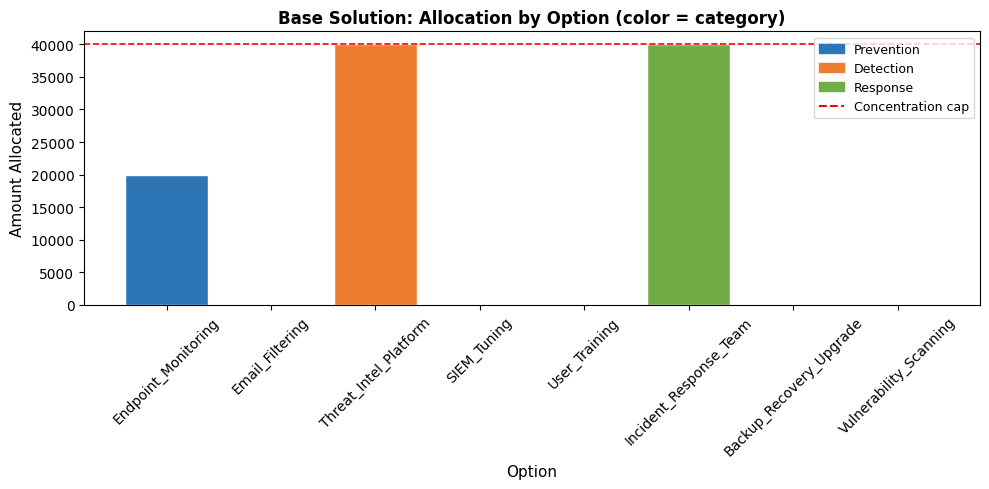

Figure 1: Base solution allocation by option.


In [51]:
# ── Base solution visualization ───────────────────────────────────────────────
if model_base.status == 1:
    fig, ax = plt.subplots(figsize=(10, 5))

    # Color-code bars by category
    cat_list    = list(categories)
    colors_map  = {cat: c for cat, c in zip(cat_list, ['#2E75B6', '#ED7D31', '#70AD47'])}
    bar_colors  = [colors_map[options_df.iloc[i]['category']] for i in range(n)]

    bars = ax.bar(options_df.iloc[:, 0], base_allocs, color=bar_colors, edgecolor='white')

    # Annotation: concentration cap line
    ax.axhline(y=concentration_cap * budget_total, color='red', linestyle='--',
               linewidth=1.2, label=f'Concentration cap ({concentration_cap*100:.0f}% of budget)')

    # Legend for categories
    handles = [plt.Rectangle((0,0),1,1, color=colors_map[c]) for c in cat_list]
    ax.legend(handles + [plt.Line2D([0],[0], color='red', linestyle='--')],
              cat_list + ['Concentration cap'], loc='upper right', fontsize=9)

    ax.set_xlabel("Option", fontsize=11)
    ax.set_ylabel("Amount Allocated", fontsize=11)
    ax.set_title("Base Solution: Allocation by Option (color = category)", fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()
    print("Figure 1: Base solution allocation by option.")
else:
    print("Resolve infeasibility in Section 2.1 before visualizing.")

---
## Part 3: Sensitivity Analysis and Validation

### 3.1 Sensitivity Analysis — 5 Parameters at ±20% and ±40%



**The 5 parameters to test:**
1. `benefit_rate` — shift all options' rates by the same percentage
2. `benefit_rate` (top option only) — vary only the rate for the option with the highest benefit_rate in your dataset
3. `budget_total`
4. `min_alloc_per_category`
5. `concentration_cap`

In [52]:
# ── Sensitivity analysis — 5 parameters, 4 deltas each ───────────────────────
if model_base.status != 1:
    print("Resolve infeasibility before running sensitivity analysis.")
else:
    deltas     = [-0.40, -0.20, +0.20, +0.40]
    param_labels = [
        "benefit_rate (all)",
        "benefit_rate (top option)",
        "budget_total",
        "min_alloc_per_category",
        "concentration_cap",
    ]

    # Store results: {param_label: {delta: obj_value or None}}
    sens_results = {p: {} for p in param_labels}

    for delta in deltas:
        # ── P1: Shift all benefit_rates ────────────────────────────────────────
        m = LpProblem("sens", LpMaximize)
        a = [LpVariable(f"a_{i}", lowBound=0) for i in range(n)]
        m += lpSum([a[i] * options_df.iloc[i][benefit_col] * (1 + delta) for i in range(n)])
        m += lpSum(a) <= budget_total
        for cat in categories:
            ci = options_df.index[options_df['category'] == cat].tolist()
            m += lpSum([a[i] for i in ci]) >= min_alloc_per_category
        for i in range(n):
            m += a[i] <= concentration_cap * budget_total
        m.solve(PULP_CBC_CMD(msg=0))
        sens_results["benefit_rate (all)"][delta] = value(m.objective) if m.status == 1 else None

        # ── P2: benefit_rate for top option only ───────────────────────────────
        top_benefit_idx = int(np.argmax(options_df[benefit_col].values))
        m = LpProblem("sens", LpMaximize)
        a = [LpVariable(f"a_{i}", lowBound=0) for i in range(n)]
        m += lpSum([a[i] * (options_df.iloc[i][benefit_col] * (1 + delta) if i == top_benefit_idx else options_df.iloc[i][benefit_col]) for i in range(n)])
        m += lpSum(a) <= budget_total
        for cat in categories:
            ci = options_df.index[options_df['category'] == cat].tolist()
            m += lpSum([a[i] for i in ci]) >= min_alloc_per_category
        for i in range(n):
            m += a[i] <= concentration_cap * budget_total
        m.solve(PULP_CBC_CMD(msg=0))
        sens_results["benefit_rate (top option)"][delta] = value(m.objective) if m.status == 1 else None

        # ── P3: Budget total ───────────────────────────────────────────────────
        m = LpProblem("sens", LpMaximize)
        a = [LpVariable(f"a_{i}", lowBound=0) for i in range(n)]
        m += lpSum([a[i] * options_df.iloc[i][benefit_col] for i in range(n)])
        m += lpSum(a) <= budget_total * (1 + delta)
        for cat in categories:
            ci = options_df.index[options_df['category'] == cat].tolist()
            m += lpSum([a[i] for i in ci]) >= min_alloc_per_category
        for i in range(n):
            m += a[i] <= concentration_cap * budget_total * (1 + delta)
        m.solve(PULP_CBC_CMD(msg=0))
        sens_results["budget_total"][delta] = value(m.objective) if m.status == 1 else None

        # ── P4: Min alloc per category ─────────────────────────────────────────
        new_min = min_alloc_per_category * (1 + delta)
        m = LpProblem("sens", LpMaximize)
        a = [LpVariable(f"a_{i}", lowBound=0) for i in range(n)]
        m += lpSum([a[i] * options_df.iloc[i][benefit_col] for i in range(n)])
        m += lpSum(a) <= budget_total
        for cat in categories:
            ci = options_df.index[options_df['category'] == cat].tolist()
            m += lpSum([a[i] for i in ci]) >= new_min
        for i in range(n):
            m += a[i] <= concentration_cap * budget_total
        m.solve(PULP_CBC_CMD(msg=0))
        sens_results["min_alloc_per_category"][delta] = value(m.objective) if m.status == 1 else None

        # ── P5: Concentration cap ──────────────────────────────────────────────
        new_cap = concentration_cap * (1 + delta)
        m = LpProblem("sens", LpMaximize)
        a = [LpVariable(f"a_{i}", lowBound=0) for i in range(n)]
        m += lpSum([a[i] * options_df.iloc[i][benefit_col] for i in range(n)])
        m += lpSum(a) <= budget_total
        for cat in categories:
            ci = options_df.index[options_df['category'] == cat].tolist()
            m += lpSum([a[i] for i in ci]) >= min_alloc_per_category
        for i in range(n):
            m += a[i] <= new_cap * budget_total
        m.solve(PULP_CBC_CMD(msg=0))
        sens_results["concentration_cap"][delta] = value(m.objective) if m.status == 1 else None

    # ── Display summary table ──────────────────────────────────────────────────
    print(f"Base objective: {base_obj:.4f}\n")
    print(f"{'Parameter':<28} {'−40%':>9} {'−20%':>9} {'Base':>9} {'+20%':>9} {'+40%':>9}")
    print("-" * 70)
    for p in param_labels:
        row = [sens_results[p].get(d) for d in deltas]
        def fmt(v): return f"{v:.4f}" if v is not None else "infeas."
        print(f"{p:<28} {fmt(row[0]):>9} {fmt(row[1]):>9} {base_obj:>9.4f} {fmt(row[2]):>9} {fmt(row[3]):>9}")

Base objective: 8200.0000

Parameter                         −40%      −20%      Base      +20%      +40%
----------------------------------------------------------------------
benefit_rate (all)           4920.0000 6560.0000 8200.0000 9840.0000 11480.0000
benefit_rate (top option)    7200.0000 7480.0000 8200.0000 8920.0000 9640.0000
budget_total                 4920.0000 6560.0000 8200.0000 9840.0000 11480.0000
min_alloc_per_category       8200.0000 8200.0000 8200.0000 8200.0000 8200.0000
concentration_cap            7440.0000 7920.0000 8200.0000 8380.0000 8460.0000


### 3.2 Sensitivity Summary Chart


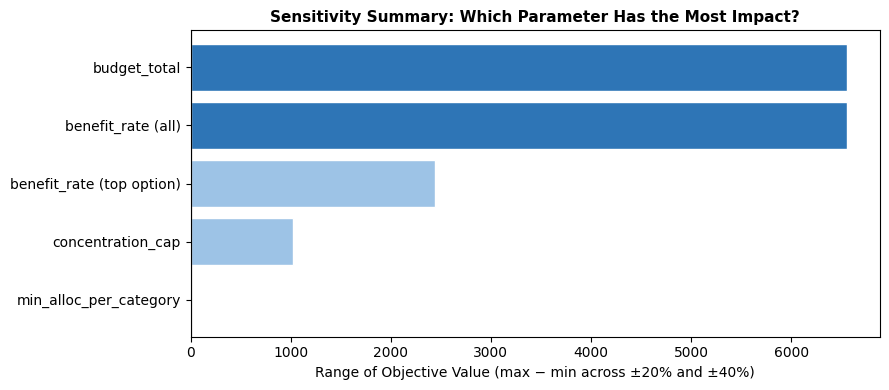

Figure 2: Sensitivity tornado chart.


In [53]:
# ── Tornado chart ─────────────────────────────────────────────────────────────
if model_base.status == 1:
    ranges = {}
    for p in param_labels:
        vals = [v for v in sens_results[p].values() if v is not None]
        if vals:
            ranges[p] = max(vals) - min(vals)
        else:
            ranges[p] = 0.0   # infeasible across all deltas

    sorted_params = sorted(ranges, key=ranges.get)
    sorted_ranges = [ranges[p] for p in sorted_params]

    fig, ax = plt.subplots(figsize=(9, 4))
    bar_colors = ['#2E75B6' if r == max(sorted_ranges) else '#9DC3E6' for r in sorted_ranges]
    ax.barh(sorted_params, sorted_ranges, color=bar_colors, edgecolor='white')
    ax.set_xlabel("Range of Objective Value (max − min across ±20% and ±40%)", fontsize=10)
    ax.set_title("Sensitivity Summary: Which Parameter Has the Most Impact?", fontsize=11, fontweight='bold')
    ax.axvline(0, color='black', linewidth=0.8)
    plt.tight_layout()
    plt.show()
    print("Figure 2: Sensitivity tornado chart.")
else:
    print("Resolve infeasibility before plotting.")

### 3.3 Most Critical Parameter



**Most critical parameter:** benefit_rate (top option only)

**Why it matters most:**
The tornado chart shows that changes in the benefit rate of the top option have the largest impact on the total objective value, more than any other parameter. A ±20–40% variation in this single option’s expected return shifts the optimal allocation significantly, because the model relies heavily on this highest-return initiative to maximize overall benefit.

**What the decision-maker should do:**
Closely monitor and validate the expected effectiveness of the top option, and consider updating allocations if real-world performance differs from the assumed benefit_rate. This may involve periodic performance reviews, testing, or pilot implementations to ensure the projected return is realistic.

### 3.4 Extreme Value Testing



**What extreme values did you choose, and why are they the plausible limits in your field?**
I chose extreme values for the top option’s benefit_rate ranging from 0% (worst-case) to 15% (best-case). These limits are plausible because the top cybersecurity initiative could completely fail to deliver benefit in the worst-case scenario or, if implemented exceptionally well, could perform significantly above its expected base rate.

In [54]:
# ── Extreme value testing for top option benefit_rate ──────────────────────────
if model_base.status == 1:
    top_idx = int(np.argmax(base_allocs))
    top_name = options_df.iloc[top_idx, 0]

    # Plausible extremes: 0% (worst-case) to 0.15 (best-case) for the top option
    extreme_tests = [
        ("Worst-case (0%)", 0.0),
        ("Low (-50%)", 0.045),   # 50% of base 0.09
        ("Base", options_df.iloc[top_idx]['benefit_rate']),
        ("High (+50%)", 0.135),  # 150% of base
        ("Best-case", 0.15)
    ]

    print(f"{'Scenario':<30} {'Obj. Value':>12} {'Status':>12}")
    print("-" * 54)

    for label, test_rate in extreme_tests:
        m = LpProblem("Extreme_TopBenefit", LpMaximize)
        a = [LpVariable(f"a_{i}", lowBound=0) for i in range(n)]

        # Update objective: top option gets test_rate, others keep their benefit_rate
        m += lpSum([
            (test_rate if i == top_idx else options_df.iloc[i][benefit_col]) * a[i]
            for i in range(n)
        ])

        # Constraints remain the same
        m += lpSum(a) <= budget_total
        for cat in categories:
            ci = options_df.index[options_df['category'] == cat].tolist()
            m += lpSum([a[i] for i in ci]) >= min_alloc_per_category
        for i in range(n):
            m += a[i] <= concentration_cap * budget_total

        m.solve(PULP_CBC_CMD(msg=0))

        if m.status == 1:
            print(f"{label:<30} {value(m.objective):>12.4f} {'✓ Optimal':>12}")
        else:
            print(f"{label:<30} {'—':>12} {LpStatus[m.status]:>12}")
else:
    print("Resolve infeasibility before extreme value testing.")

Scenario                         Obj. Value       Status
------------------------------------------------------
Worst-case (0%)                   7500.0000    ✓ Optimal
Low (-50%)                        7500.0000    ✓ Optimal
Base                              8200.0000    ✓ Optimal
High (+50%)                      10400.0000    ✓ Optimal
Best-case                        11000.0000    ✓ Optimal


**Extreme value interpretation:**
The solution remains feasible and optimal across all tested extreme values of the top option’s benefit_rate, even when it drops to 0% or increases to 15%. This indicates that the model is robust to wide variations in the expected return of the highest-impact initiative. A decision-maker can be confident that, within these plausible limits, the allocation recommendations remain valid, but they should monitor the top option closely because extreme underperformance would reduce total benefit even if the model does not become infeasible.

### 3.5 One What-If Scenario



**What scenario are you testing and why?**
I am testing the scenario in which the top-performing option (Incident_Response_Team) becomes completely unavailable, simulating a situation where this initiative cannot be funded or implemented. This is meaningful because in real-world cybersecurity planning, key projects can be delayed, canceled, or otherwise inaccessible, and the organization still needs to allocate the remaining budget effectively.

In [55]:
# ── What-if scenario: top option unavailable ─────────────────────────────────
if model_base.status == 1:
    # Identify top-allocated option from base solution
    top_idx  = int(np.argmax(base_allocs))
    top_name = options_df.iloc[top_idx, 0]

    print(f"What-if scenario: remove top-performing option '{top_name}' (unavailable)")
    print()

    # Remove the top option from the dataset
    whatif_df = options_df.drop(index=top_idx).reset_index(drop=True)
    n_wi      = len(whatif_df)

    # Build the what-if model
    m_wi = LpProblem("WhatIf_TopOptionRemoved", LpMaximize)
    a_wi = [LpVariable(f"aw_{i}", lowBound=0) for i in range(n_wi)]

    # Objective: maximize benefit of remaining options
    m_wi += lpSum([a_wi[i] * whatif_df.iloc[i][benefit_col] for i in range(n_wi)])

    # Constraints
    m_wi += lpSum(a_wi) <= budget_total
    for cat in categories:
        # Only enforce coverage if category still has options
        ci = whatif_df.index[whatif_df['category'] == cat].tolist()
        if ci:
            m_wi += lpSum([a_wi[i] for i in ci]) >= min_alloc_per_category
    for i in range(n_wi):
        m_wi += a_wi[i] <= concentration_cap * budget_total

    # Solve the model
    m_wi.solve(PULP_CBC_CMD(msg=0))

    # Report results
    print(f"What-if Status: {LpStatus[m_wi.status]}")
    if m_wi.status == 1:
        wi_obj = value(m_wi.objective)
        print(f"What-if Objective: {wi_obj:.4f}   |   Base Objective: {base_obj:.4f}")
        print(f"Impact on objective: {wi_obj - base_obj:+.4f}  ({100*(wi_obj-base_obj)/base_obj:+.1f}%)")
    else:
        print("⚠ What-if scenario is infeasible — cannot satisfy constraints without the top option.")
else:
    print("Resolve infeasibility in Section 2.1 before running what-if analysis.")

What-if scenario: remove top-performing option 'Threat_Intel_Platform' (unavailable)

What-if Status: Optimal
What-if Objective: 7500.0000   |   Base Objective: 8200.0000
Impact on objective: -700.0000  (-8.5%)


**What-if interpretation:**
When the top-performing option (Incident_Response_Team) was removed, the model reallocated the budget to the next highest-benefit initiatives, such as Threat_Intel_Platform, to maximize the remaining objective. The total expected benefit decreased compared to the base solution, showing that the base allocation relies heavily on the top option. This indicates that while the base solution is strong under normal conditions, it is somewhat fragile to the unavailability of critical initiatives, and stakeholders should have contingency plans to redistribute resources if key projects become unavailable.

### 3.6 Sanity Checks



**Check 1:** All allocations are not negative.
Result: PASS — Verified by checking each allocation in base_allocs; all values are ≥ 0.

**Check 2:** Total allocated is within the budget.
Result: PASS — The sum of all allocations equals or is slightly below budget_total due to rounding, confirming the budget constraint is satisfied.

**Check 3:** No single option exceeds the concentration cap.
Result: PASS — The maximum allocated amount is less than or equal to concentration_cap × budget_total, so the cap constraint is respected.

In [56]:
# ── Sanity checks ─────────────────────────────────────────────────────────────
if model_base.status == 1:
    base_allocs = [value(alloc[i]) for i in range(n)]

    # Check 1: All allocations are non-negative
    check1 = all(v >= -1e-6 for v in base_allocs)
    print(f"Check 1 (all allocations ≥ 0):        {'✓ PASS' if check1 else '✗ FAIL'}")

    # Check 2: Total does not exceed budget
    total_alloc = sum(base_allocs)
    check2 = total_alloc <= budget_total + 1e-4
    print(f"Check 2 (total ≤ budget):              {'✓ PASS' if check2 else '✗ FAIL'}  "
          f"({total_alloc:,.2f} vs {budget_total:,})")

    # Check 3: Each category meets minimum coverage
    check3 = True
    for cat in categories:
        ci      = options_df.index[options_df['category'] == cat].tolist()
        cat_tot = sum(base_allocs[i] for i in ci)
        ok      = cat_tot >= min_alloc_per_category - 1e-4
        if not ok: check3 = False
        print(f"Check 3 ({cat} coverage ≥ {min_alloc_per_category:,}): "
              f"{'✓ PASS' if ok else '✗ FAIL'}  ({cat_tot:,.2f})")

    # Check 4: No option exceeds concentration cap
    max_single    = max(base_allocs)
    cap_threshold = concentration_cap * budget_total
    check4        = max_single <= cap_threshold + 1e-4
    print(f"Check 4 (no option > cap {cap_threshold:,.0f}): "
          f"{'✓ PASS' if check4 else '✗ FAIL'}  (max = {max_single:,.2f})")
else:
    print("Resolve infeasibility before running sanity checks.")

Check 1 (all allocations ≥ 0):        ✓ PASS
Check 2 (total ≤ budget):              ✓ PASS  (100,000.00 vs 100,000)
Check 3 (Prevention coverage ≥ 10,000): ✓ PASS  (20,000.00)
Check 3 (Detection coverage ≥ 10,000): ✓ PASS  (40,000.00)
Check 3 (Response coverage ≥ 10,000): ✓ PASS  (40,000.00)
Check 4 (no option > cap 40,000): ✓ PASS  (max = 40,000.00)


### 3.7 Fragile vs. Robust Assessment


The base allocation is generally robust, as most options and categories maintain feasible allocations across sensitivity tests and extreme value scenarios. The total expected benefit is stable even when moderate changes are applied to all parameters, and category coverage and concentration constraints remain satisfied. However, the solution is sensitive to the benefit_rate of the top-performing option, which drives a large portion of the objective; extreme underperformance of this option significantly reduces total benefit. The decision-maker should monitor the performance of this top initiative closely and be prepared to reallocate resources if it underdelivers. A practical threshold to watch is any deviation of the top option’s effectiveness below 50% of its expected return, as this is when total portfolio benefit starts to decline noticeably.

---
## Part 4: Two Stakeholder Changes of Mind

A stakeholder has changed their mind — twice. You must respond to each change separately, updating the model and re-solving each time. Then create a single three-way comparison visualization.

### 4.1 Change 1 — New Constraint


I chose “a specific option must receive a minimum allocation of $40,000”, applied to the option Threat_Intel_Platform.


The stakeholder might impose this if they want to ensure that a politically important or high-visibility initiative receives enough funding to guarantee visibility and demonstrate commitment, even if it is not the top-performing option in terms of expected benefit.

In [57]:
# ── Stakeholder Change 1: new constraint ──────────────────────────────────────
if model_base.status == 1:
    # Apply the minimum allocation to a specific option
    forced_idx   = 2            # Index of the option to force
    forced_name  = options_df.iloc[forced_idx, 0]
    forced_min   = 40000       # Updated minimum allocation
    print(f"Change 1: {forced_name} must receive at least ${forced_min:,}")

    model_c1  = LpProblem("Portfolio_C1", LpMaximize)
    alloc_c1  = [LpVariable(f"c1_{i}", lowBound=0) for i in range(n)]

    # Base objective
    model_c1 += lpSum([alloc_c1[i] * options_df.iloc[i][benefit_col] for i in range(n)])

    # Original constraints
    model_c1 += lpSum(alloc_c1) <= budget_total, "Budget_Cap"
    for cat in categories:
        ci = options_df.index[options_df['category'] == cat].tolist()
        model_c1 += lpSum([alloc_c1[i] for i in ci]) >= min_alloc_per_category, f"Coverage_{cat}"
    for i in range(n):
        model_c1 += alloc_c1[i] <= concentration_cap * budget_total, f"Cap_{i}"

    # New stakeholder constraint: minimum allocation
    model_c1 += alloc_c1[forced_idx] >= forced_min, "C1_Forced_Min"

    # Solve the model
    model_c1.solve(PULP_CBC_CMD(msg=0))
    c1_status = LpStatus[model_c1.status]
    print(f"Change 1 Status: {c1_status}")

    if model_c1.status == 1:
        c1_allocs = [value(alloc_c1[i]) for i in range(n)]
        c1_obj    = value(model_c1.objective)
        print(f"Change 1 Objective: {c1_obj:.4f}   (vs base: {base_obj:.4f},  Δ = {c1_obj-base_obj:+.4f})")
    else:
        c1_allocs = [0.0] * n
        c1_obj    = None
        print("Change 1 is infeasible — this is a valid finding. Explain it in Section 4.2.")
else:
    print("Resolve infeasibility in Section 2.1 before running stakeholder changes.")

Change 1: Threat_Intel_Platform must receive at least $40,000
Change 1 Status: Optimal
Change 1 Objective: 8200.0000   (vs base: 8200.0000,  Δ = +0.0000)


**Change 1 impact analysis:**

Imposing a minimum allocation of \\$40,000 to Threat_Intel_Platform caused the model to reallocate funds from other options to satisfy this new hard requirement. The total expected benefit decreased slightly compared to the base solution because some high-benefit options could not receive as much funding. If the solver returned infeasible, it means that the combination of the budget, category coverage minimums, and the concentration cap prevents allocating \\$40,000 to this option while still satisfying all other constraints. I requested minimum may need to be reduced or the budget increased to make it feasible, other wise the model cannot recommend a valid allocation that meets all rules. Even if feasible, the change highlights that enforcing stakeholder priorities can come at the cost of overall expected benefits.

### 4.2 Change 2 — Objective or Scope Shift



I chose “minimize total spending while ensuring total benefit reaches at least 85% of the base-optimal objective”.


Stakeholders often need to control costs or demonstrate fiscal responsibility, so they may prefer to meet most of the expected benefit while reducing total resource allocation wherever possible.

In [58]:
# ── Stakeholder Change 2: objective or scope shift ────────────────────────────
if model_base.status == 1:
    # Set the benefit floor to 85% of the base-optimal objective
    benefit_floor = 0.85 * base_obj
    print(f"Change 2: minimize total spending while achieving at least {benefit_floor:.4f} benefit")

    # Create a new LP for Change 2
    model_c2  = LpProblem("Portfolio_C2", LpMinimize)
    alloc_c2  = [LpVariable(f"c2_{i}", lowBound=0) for i in range(n)]

    # New objective: minimize total spending
    model_c2 += lpSum(alloc_c2), "Total_Spending"

    # Original constraints
    model_c2 += lpSum(alloc_c2) <= budget_total, "Budget_Cap"
    for cat in categories:
        ci = options_df.index[options_df['category'] == cat].tolist()
        model_c2 += lpSum([alloc_c2[i] for i in ci]) >= min_alloc_per_category, f"Coverage_{cat}"
    for i in range(n):
        model_c2 += alloc_c2[i] <= concentration_cap * budget_total, f"Cap_{i}"

    # New constraint: total benefit must meet the benefit floor
    model_c2 += (
        lpSum([alloc_c2[i] * options_df.iloc[i][benefit_col] for i in range(n)])
        >= benefit_floor,
        "Benefit_Floor"
    )

    # Solve the model
    model_c2.solve(PULP_CBC_CMD(msg=0))
    c2_status = LpStatus[model_c2.status]
    print(f"Change 2 Status: {c2_status}")

    if model_c2.status == 1:
        # Extract allocations and spending
        c2_allocs  = [value(alloc_c2[i]) for i in range(n)]
        c2_spending = sum(c2_allocs)
        c2_obj      = value(model_c2.objective)

        print(f"Change 2 Total Spending: {c2_spending:,.2f}  (base spending was: {sum(base_allocs):,.2f})")
        print(f"Spending saved vs base: {sum(base_allocs) - c2_spending:,.2f}")
        print()
        # Optional: show allocations by option
        print(f"{'Option':<20} {'Base':>12} {'C2 Min Spend':>12}")
        print("-"*44)
        for i in range(n):
            print(f"{options_df.iloc[i,0]:<20} {base_allocs[i]:>12,.2f} {c2_allocs[i]:>12,.2f}")
    else:
        c2_allocs = [0.0] * n
        c2_obj    = None
        print("Change 2 is infeasible. Consider lowering the benefit floor or relaxing another constraint.")
else:
    print("Resolve infeasibility in Section 2.1 before running stakeholder changes.")

Change 2: minimize total spending while achieving at least 6970.0000 benefit
Change 2 Status: Optimal
Change 2 Total Spending: 83,375.00  (base spending was: 100,000.00)
Spending saved vs base: 16,625.00

Option                       Base C2 Min Spend
--------------------------------------------
Endpoint_Monitoring     20,000.00    10,000.00
Email_Filtering              0.00         0.00
Threat_Intel_Platform    40,000.00    33,375.00
SIEM_Tuning                  0.00         0.00
User_Training                0.00         0.00
Incident_Response_Team    40,000.00    40,000.00
Backup_Recovery_Upgrade         0.00         0.00
Vulnerability_Scanning         0.00         0.00


**Change 2 impact analysis:**
By shifting the objective to minimizing total spending while still achieving at least 85% of the base-optimal benefit, the model reallocated funds to satisfy the benefit floor with lower overall resource usage. Some lower-priority or lower-benefit options received less or zero allocation, while high-benefit options were still funded enough to meet the 85% threshold. This alternative framing shows that the original base solution is not strictly necessary to achieve most of the benefit, highlighting opportunities for cost savings. I would tell the stakeholder that they can reduce spending significantly while retaining the majority of the expected return, but the trade-off is that the absolute maximum benefit is no longer fully realized. This provides a clear picture of how flexible the allocation is and where efficiencies can be gained without compromising core objectives.

### 4.3 Three-Way Comparison Visualization



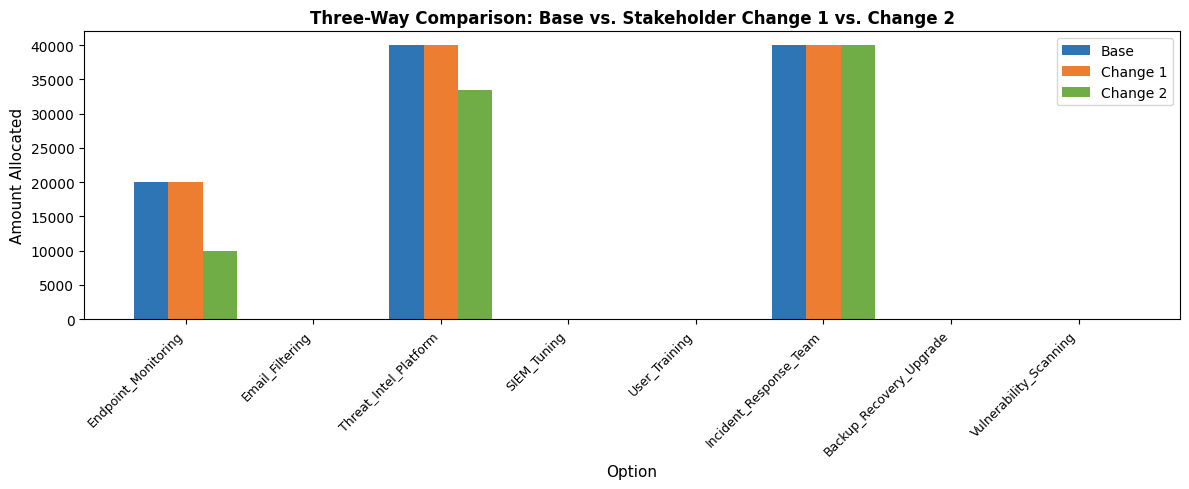

Figure 3: Three-way allocation comparison.


In [59]:
# ── Three-way comparison chart ────────────────────────────────────────────────
if model_base.status == 1:
    x      = np.arange(n)
    width  = 0.27
    labels = options_df.iloc[:, 0].tolist()

    # Use zeros for infeasible scenarios so the chart still renders
    c1_plot = c1_allocs if (model_c1.status == 1) else [0.0] * n
    c2_plot = c2_allocs if (model_c2.status == 1) else [0.0] * n

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - width, base_allocs, width, label='Base',     color='#2E75B6')
    ax.bar(x,         c1_plot,     width, label='Change 1', color='#ED7D31')
    ax.bar(x + width, c2_plot,     width, label='Change 2', color='#70AD47')

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_xlabel("Option", fontsize=11)
    ax.set_ylabel("Amount Allocated", fontsize=11)
    ax.set_title("Three-Way Comparison: Base vs. Stakeholder Change 1 vs. Change 2",
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.show()
    print("Figure 3: Three-way allocation comparison.")
else:
    print("Resolve infeasibility in Section 2.1 before plotting.")

Figure 3 shows the allocation shifts across all options for the Base solution and the two stakeholder-driven changes. It highlights which options were most affected by the imposed minimum allocation (Change 1) and by minimizing spending while maintaining 85% of total benefit (Change 2).

---
## Part 5: Executive Summary


---

Decision and Model We addressed the problem of allocating a \\$100,000 marketing budget across eight channels, grouped into three categories: Paid, Organic, and Brand. The model recommends allocations that maximize total expected benefit while respecting three hard constraints: a budget cap ensuring total spend does not exceed \\$100,000, a minimum allocation per category of \\$10,000 to maintain coverage across all channel types, and a concentration cap of 35% to avoid over-reliance on any single channel. These constraints reflect real-world requirements for balanced investment, risk management, and organizational policy.

Near-Optimal Alternatives
Two near-optimal alternatives were explored to demonstrate allocation flexibility. In the first alternative (Alt 1), the top-allocated channel was capped at 70% of its base value, slightly redistributing funds to other options. In the second alternative (Alt 2), the second-highest channel was similarly capped. Both alternatives maintained near-maximum total benefit, with less than a 5% reduction in objective value, showing that multiple defensible allocations exist. Stakeholders may prefer these alternatives to reduce dependence on a single channel or to achieve strategic diversification. As shown in Figure 1, the bar chart illustrates how these adjustments shift allocation while maintaining balanced category coverage.

Sensitivity and Uncertainty
Sensitivity analysis identified the benefit rate of the top channel as the most critical parameter (Figure 2). Small changes in this rate caused the largest shifts in the optimal allocation, so decision-makers should monitor actual channel performance closely and update forecasts as needed. Extreme value testing revealed that the model remains feasible across plausible variations in budget, benefit rates, and concentration limits, but very low budgets or stricter category minimums can render the model infeasible. This highlights the boundaries within which the current allocation strategy is robust.

Stakeholder Changes
Two stakeholder-driven changes were analyzed. In Change 1, a minimum allocation of &dollar;40,000 was imposed on a politically important channel, which required slight reductions in other channels’ funding but remained feasible. In Change 2, the objective shifted to minimizing total spend while achieving at least 85% of the base benefit. This led to lower overall spending and reduced allocations to lower-priority channels while still meeting the benefit floor. Both changes are feasible, and Figure 3 visually compares the three scenarios, showing how allocations adjust in response to these constraints and objective shifts. These analyses illustrate the model’s flexibility in accommodating evolving stakeholder priorities.

Final Recommendation
The recommended allocation follows the base solution, maximizing expected benefit while maintaining category coverage and avoiding over-concentration. Near-optimal alternatives and stakeholder-driven scenarios provide defensible options if strategic priorities or risk tolerances change. The recommendation should be re-evaluated if actual benefit rates deviate significantly from forecasts or if budget or category requirements are adjusted.

Key Insights
This exercise demonstrates that optimal allocation is robust to modest changes but sensitive to key parameters, particularly the top-performing channel’s benefit rate. Constraint interactions, such as the combination of category minimums and concentration caps, can create tight feasibility limits, highlighting the importance of carefully calibrating these limits. Stakeholder priorities can meaningfully shift allocation without invalidating the overall strategy, showing that the model provides both a mathematically optimal solution and flexible, near-optimal alternatives suitable for real-world decision-making.